In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import plotly.express as px

In [49]:
epidist_data = pd.read_csv('./Data/20251101184108_epidist_heatmap_data.csv')
bepidist_data = pd.read_csv('./Data/20251101184108_bepidist_heatmap_data.csv')
epidist_data = epidist_data.apply(pd.to_numeric)
bepidist_data = bepidist_data.apply(pd.to_numeric)
print(bepidist_data['V'].unique().tolist())
print(bepidist_data['T'].unique().tolist())

[0.01, 0.0164, 0.0229, 0.0293, 0.0357, 0.0421, 0.0486, 0.055, 0.0614, 0.0679, 0.0743, 0.0807, 0.0871, 0.0936, 0.1]
[4, 6, 8, 10, 12, 14, 16, 18]


### Example of disease peaks differences depeding on utility shape parameter

-0.38915999999999995
-0.3487
-0.39788000000000007
-0.32549999999999996
-0.2624
-0.23214


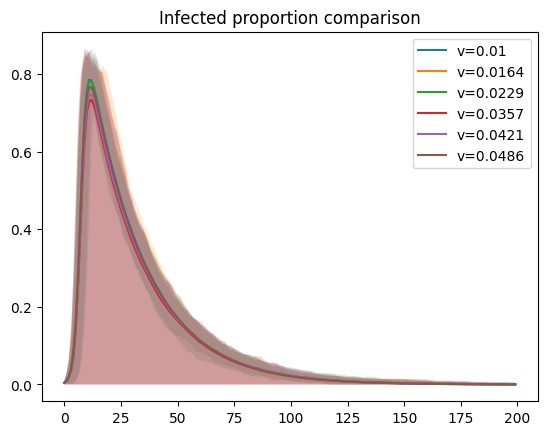

In [9]:
vs = [0.01, 0.0164, 0.0229, 0.0293, 0.0357, 0.0421, 0.0486]
T = 6
n = 500

plt.figure()

for v in vs:

    epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
    bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]

    mean = (epidist['i_mean']/n).tolist()
    lower = (epidist['i_min']/n).tolist()
    upper = (epidist['i_max']/n).tolist()

    meanb = (bepidist['i_mean']/n).tolist()
    lowerb = (bepidist['i_min']/n).tolist()
    upperb = (bepidist['i_max']/n).tolist()

    diff = np.nanmax(mean) - np.nanmax(meanb)
    print(diff)

    # plt.plot(mean,'-b', label="Mean classic model")
    # # fill the area with black color, opacity 0.15
    # plt.fill_between(list(range(len(mean))), upper, lower, color="b", alpha=0.2)

    plt.plot(meanb, label=f"v={v}")
    plt.fill_between(range(len(meanb)), upperb, lowerb, alpha=0.2)

plt.title("Infected proportion comparison")
plt.legend(loc="upper right")

plt.show()

[0.01, 0.0164, 0.0229, 0.0293, 0.0357, 0.0421, 0.0486, 0.055, 0.0614, 0.0679, 0.0743, 0.0807, 0.0871, 0.0936, 0.1]
[np.float64(0.01), '', np.float64(0.02), '', np.float64(0.04), '', np.float64(0.05), '', np.float64(0.06), '', np.float64(0.07), '', np.float64(0.09), '', np.float64(0.1)]


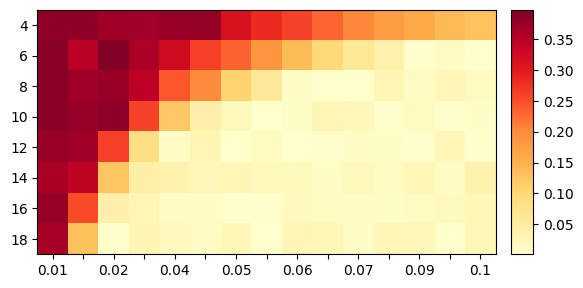

In [25]:
data_diff = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        
        epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean = (epidist['i_mean']/n).tolist()
        meanb = (bepidist['i_mean']/n).tolist()
        
        diff = np.nanmax(mean) - np.nanmax(meanb)
        
        data_diff = pd.concat([data_diff, pd.DataFrame({
            'V': [v],
            'T': [T],
            'diff': [np.abs(diff)]
        })], ignore_index=True)
plot1_data = data_diff.pivot(index='V', columns='T', values='diff')
# Labels
xlabs0 = list(plot1_data.index)
xlabs = []
for i, x in enumerate(xlabs0):
    if i % 2 == 0:
        xlabs.append(np.round(x,2))
    else:
        xlabs.append('')

print(xlabs0)
print(xlabs)

ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

# for dat in data:
#     vals = [str(round(val, 4)) for val in list(dat)]
#     vals = f"{{{','.join(vals)}}},"
#     print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = "YlOrRd")

# Add the labels
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
# plt.setp(ax.get_xticklabels(), rotation = 90,
#          ha = "right", rotation_mode = "anchor")

# Add the color bar
# cbar = ax.figure.colorbar(im, ax = ax)

# Create colorbar with same height as heatmap
from mpl_toolkits.axes_grid1 import make_axes_locatable
# Create an axes divider for the heatmap
divider = make_axes_locatable(ax)
# Append a new axes for the colorbar, same height as ax
cax = divider.append_axes("right", size="5%", pad=0.15)
# Add colorbar to the new axes
cbar = plt.colorbar(im, cax=cax)

# plt.xlabel("Population Risk Sensitivity")
# plt.ylabel("Planning horizon (days)")
plt.show()

### Main figure: global vs local efforts

In [1]:
# v = 0.05
# T = 15
# n = 500
# epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
# bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]

# mean_all = bepidist['edgecount_mean'].tolist()
# lower_all = bepidist['edgecount_min'].tolist()
# upper_all = bepidist['edgecount_max'].tolist()

# mean_sus = bepidist['suscedgecount_mean'].tolist()
# lower_sus = bepidist['suscedgecount_min'].tolist()
# upper_sus = bepidist['suscedgecount_max'].tolist()

# print(np.nanmin(bepidist['suscedgecount_mean'].tolist()))

# plt.figure()
# plt.plot(mean_all[0:50],'-k', label="Network avg. edges reduction")
# plt.fill_between(range(50), upper_all[0:50], lower_all[0:50], color="k", alpha=0.2)
# plt.plot(mean_sus[0:50], linestyle='--', color='b', label="Individuals avg. edges reduction")
# plt.fill_between(range(50), upper_sus[0:50], lower_sus[0:50], color="b", alpha=0.2)
# plt.title(f"Global and local behavioral responses (v={v}, T={T})")
# plt.legend(loc="lower right")
# plt.show()

### Min Avg. Edge Reduction (Global/Local)

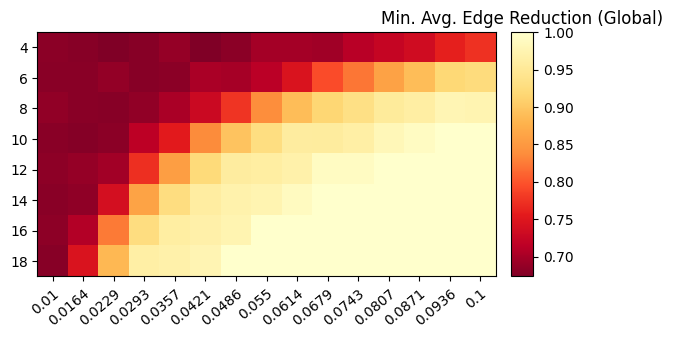

In [43]:
data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_sus = bepidist['edgecount_mean'].tolist()
        min_ctc_sus = np.nanmin(mean_sus)
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [min_ctc_sus]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')

# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

##### Reverse colormap
import matplotlib as mpl

def reverse_colourmap(cmap, name = 'my_cmap_r'):
    """
    In: 
    cmap, name 
    Out:
    my_cmap_r

    Explanation:
    t[0] goes from 0 to 1
    row i:   x  y0  y1 -> t[0] t[1] t[2]
                   /
                  /
    row i+1: x  y0  y1 -> t[n] t[1] t[2]

    so the inverse should do the same:
    row i+1: x  y1  y0 -> 1-t[0] t[2] t[1]
                   /
                  /
    row i:   x  y1  y0 -> 1-t[n] t[2] t[1]
    """        
    reverse = []
    k = []   

    for key in cmap._segmentdata:    
        k.append(key)
        channel = cmap._segmentdata[key]
        data = []

        for t in channel:                    
            data.append((1-t[0],t[2],t[1]))            
        reverse.append(sorted(data))    

    LinearL = dict(zip(k,reverse))
    my_cmap_r = mpl.colors.LinearSegmentedColormap(name, LinearL) 
    return my_cmap_r
cmap = mpl.cm.YlOrRd
cmap_r = reverse_colourmap(cmap)    

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)


# Create colorbar with same height as heatmap
from mpl_toolkits.axes_grid1 import make_axes_locatable
# Create an axes divider for the heatmap
divider = make_axes_locatable(ax)
# Append a new axes for the colorbar, same height as ax
cax = divider.append_axes("right", size="5%", pad=0.15)
# Add colorbar to the new axes
cbar = plt.colorbar(im, cax=cax)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# # Add the color bar
# cbar = ax.figure.colorbar(im, ax = ax)
# cbar.ax.set_ylabel("Min. Avg. Edge Reduction", rotation = -90, va = "bottom")

plt.title(f"Min. Avg. Edge Reduction (Global)")
# plt.xlabel("Utility shape parameter")
# plt.ylabel("Planning horizon (days)")
plt.show()

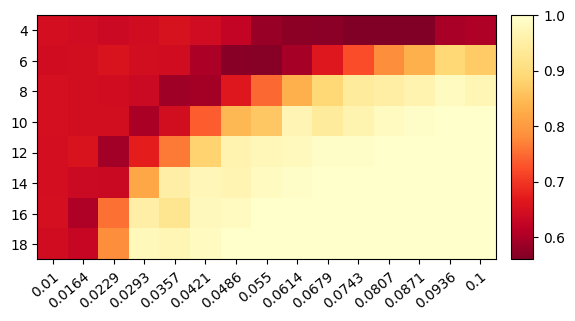

In [46]:
data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_sus = bepidist['suscedgecount_mean'].tolist()
        min_ctc_sus = np.nanmin(mean_sus)
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [min_ctc_sus]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# # Add the color bar
# cbar = ax.figure.colorbar(im, ax = ax)
# cbar.ax.set_ylabel("Min. Avg. Edge Reduction", rotation = -90, va = "bottom")

# Create colorbar with same height as heatmap
from mpl_toolkits.axes_grid1 import make_axes_locatable
# Create an axes divider for the heatmap
divider = make_axes_locatable(ax)
# Append a new axes for the colorbar, same height as ax
cax = divider.append_axes("right", size="5%", pad=0.15)
# Add colorbar to the new axes
cbar = plt.colorbar(im, cax=cax)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# plt.title(f"Min. Avg. Edge Reduction (for Susceptibles)")
# plt.xlabel("Utility shape parameter")
# plt.ylabel("Planning horizon (days)")
plt.show()

### Day lag between min edge reductions (Global/Local)

{11,11,11,12,12,12,13,10,8,8,7,8,8,7,7},
{12,11,10,10,11,10,8,8,8,7,11,12,15,14,21},
{11,11,10,12,9,8,9,13,13,19,25,17,18,0,21},
{10,10,10,9,11,11,15,18,19,20,20,14,0,0,0},
{11,10,9,12,15,21,17,1,0,0,0,0,0,0,0},
{12,11,11,14,0,1,22,0,0,0,0,0,0,0,0},
{11,11,15,1,18,0,0,0,0,0,0,0,0,0,0},
{11,12,21,1,17,0,0,0,0,0,0,0,0,0,0},


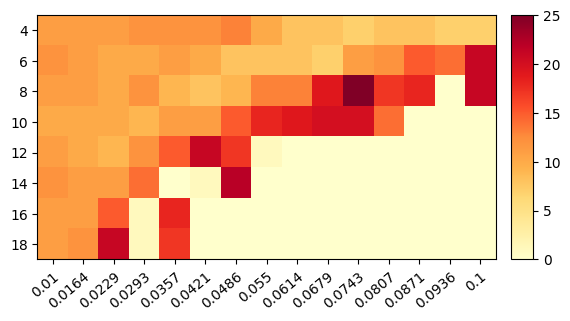

In [56]:
# ------- #

data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_ctc_ = bepidist['edgecount_mean'].tolist()
        min_ctc_day_ = np.nanargmin(mean_ctc_)
        
        mean_ctc_sus_ = bepidist['suscedgecount_mean'].tolist()
        min_ctc_day_sus_ = np.nanargmin(mean_ctc_sus_)
        
        day_lag_ = min_ctc_day_sus_ - min_ctc_day_
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [day_lag_]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap)

# Add the labels
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
# cbar = ax.figure.colorbar(im, ax = ax)
# cbar.ax.set_ylabel("Day Difference", rotation = -90, va = "bottom")

# Create colorbar with same height as heatmap
from mpl_toolkits.axes_grid1 import make_axes_locatable
# Create an axes divider for the heatmap
divider = make_axes_locatable(ax)
# Append a new axes for the colorbar, same height as ax
cax = divider.append_axes("right", size="5%", pad=0.15)
# Add colorbar to the new axes
cbar = plt.colorbar(im, cax=cax)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# I'll add the labels later
# plt.title(f"Difference of Days at Min. Avg. Edge Reduction (Susceptibles - Global)")
# plt.xlabel("Utility shape parameter")
# plt.ylabel("Planning horizon (days)")
plt.show()

### Population distributions example

In [57]:
# dist_example = pd.read_csv('./distribution_example.csv')

# dist_example = dist_example.reset_index()
# dist_example.columns = ['node', 'v', 'T']

# print('Sub population 1: More risk averse. More susceptible to diminish contacts.')
# print(dist_example.head(200)['v'].mean())
# print(dist_example.head(200)['T'].mean())

# print('Sub population 2: Less risk averse. Less susceptible to diminish contacts.')
# print(dist_example.tail(300)['v'].mean())
# print(dist_example.tail(300)['T'].mean())

In [58]:
# bepidist_data = pd.read_csv('./Data/Distribution_bepidist.csv')
# bepidist_data

In [2]:
bepidist = pd.read_csv('./Data/20251101193824_bepidist_0.05_7_figure_data.csv')
epidist = pd.read_csv('./Data/20251101193824_epidist_0.05_7_data.csv')

In [35]:
# Labels
xlabs0 = bepidist['day'].tolist()
print(xlabs0)
xlabs0 =

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200]


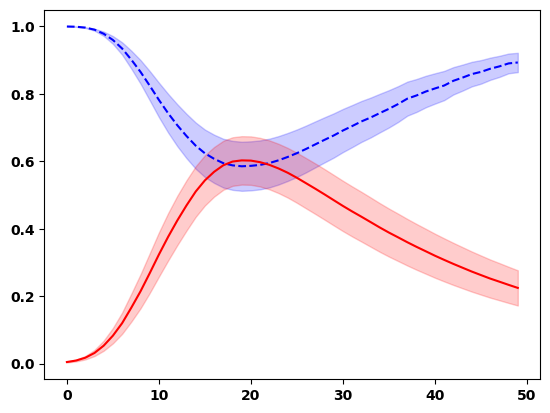

In [42]:
# bepidist = bepidist_data.copy()
# bepidist = bepidist[(bepidist['V']==0.055) & (bepidist['T']==6)]

i_mean_o = epidist['i_mean'].astype(float).tolist()
i_mean_o = [i/500 for i in i_mean_o]

i_min_o = epidist['i_min'].astype(float).tolist()
i_min_o = [m*(0.7 + (1 - (1-m))*0.3) for m in i_mean_o]

i_max_o = epidist['i_max'].astype(float).tolist()
i_max_o = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in i_mean_o]

i_mean = bepidist['i_mean'].astype(float).tolist()
i_mean = [i/500 for i in i_mean]

i_min = bepidist['i_min'].astype(float).tolist()
i_min = [m*(0.7 + (1 - (1-m))*0.3) for m in i_mean]

i_max = bepidist['i_max'].astype(float).tolist()
i_max = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in i_mean]

mean_all = bepidist['edgecount_mean'].astype(float).tolist()
lower_all = [m*(0.7 + (1 - (1-m))*0.3) for m in mean_all] # bepidist['edgecount_min'].astype(float).tolist()
upper_all = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in mean_all] # bepidist['edgecount_max'].astype(float).tolist()

mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
lower_sus = [m*(0.7 + (1 - (1-m))*0.3) for m in mean_sus] #  bepidist['suscedgecount_min'].astype(float).tolist()
upper_sus = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in mean_sus] # bepidist['suscedgecount_max'].astype(float).tolist()

top = 50

plt.figure()
# plt.plot(mean_all[0:top],'-k') #, label="Network avg. edges reduction")
# plt.fill_between(range(top), upper_all[0:top], lower_all[0:top], color="k", alpha=0.2)
plt.plot(mean_sus[0:top], linestyle='--', color='b') #, label="Individuals avg. edges reduction")
plt.fill_between(range(top), upper_sus[0:top], lower_sus[0:top], color="b", alpha=0.2)

# plt.plot(i_mean_o[0:top],'#5d7fb5', linestyle='--') #, label="Network avg. edges reduction")
# plt.fill_between(range(top), i_max_o[0:top], i_min_o[0:top], color="#afc6e7", alpha=0.3)
plt.plot(i_mean[0:top],'-r') #, label="Network avg. edges reduction")
plt.fill_between(range(top), i_max[0:top], i_min[0:top], color="r", alpha=0.2)
# # plt.legend(loc="lower right")

ax = plt.gca() # Get current axes
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')

# Save the figure
# plt.savefig('./FIGRE2A3A.png')

plt.show()

#### Examining contact behavior in subpopulations

In [17]:
bepcontacts = pd.read_csv('./Data/Distribution_bepidist_contacts.csv')
print(bepcontacts.shape)
bepcontacts

(25000, 202)


,index,node,day_0,day_1,day_2,day_3,day_4,day_5,day_6,day_7,...,day_190,day_191,day_192,day_193,day_194,day_195,day_196,day_197,day_198,day_199
0,0,0,23,23,23,23,23,22,22,21,...,23,23,23,23,23,23,23,23,23,23
1,0,1,26,26,26,26,26,26,24,24,...,26,26,26,26,26,26,26,26,26,26
2,0,2,27,27,27,27,27,27,27,26,...,27,27,27,27,27,27,27,27,27,27
3,0,3,20,20,20,20,20,18,18,18,...,20,20,20,20,20,20,20,20,20,20
4,0,4,27,27,27,27,27,26,23,23,...,27,27,27,27,27,27,27,27,27,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,49,495,25,25,25,25,25,25,25,25,...,25,25,25,25,25,25,25,25,25,25
24996,49,496,32,32,32,32,32,32,32,22,...,32,32,32,32,32,32,32,32,32,32
24997,49,497,23,23,23,23,13,16,17,20,...,23,23,23,23,23,23,23,23,23,23
24998,49,498,17,17,17,17,17,17,13,16,...,17,17,17,17,17,17,17,17,17,17


In [18]:
bepcontacts_long = pd.melt(bepcontacts, id_vars=['index', 'node'],
                           value_vars=[col for col in bepcontacts.columns if col.startswith('day')])
bepcontacts_long

,index,node,variable,value
0,0,0,day_0,23
1,0,1,day_0,26
2,0,2,day_0,27
3,0,3,day_0,20
4,0,4,day_0,27
...,...,...,...,...
4999995,49,495,day_199,25
4999996,49,496,day_199,32
4999997,49,497,day_199,23
4999998,49,498,day_199,17


In [19]:
bepcontacts_long_max = bepcontacts_long.groupby(['index', 'node'])['value'].max().reset_index()
bepcontacts_long_max.columns = ['index', 'node', 'value_max']
bepcontacts_long_max

,index,node,value_max
0,0,0,23
1,0,1,26
2,0,2,27
3,0,3,20
4,0,4,27
...,...,...,...
24995,49,495,25
24996,49,496,32
24997,49,497,23
24998,49,498,17


In [20]:
bepcontacts_long_norm = bepcontacts_long.merge(bepcontacts_long_max, left_on=['index', 'node'], right_on=['index', 'node'])
bepcontacts_long_norm['norm_value'] = bepcontacts_long_norm['value']/bepcontacts_long_norm['value_max']
bepcontacts_long_norm['pop'] = np.where(bepcontacts_long_norm['node']<200, 1, 2)
bepcontacts_long_norm = bepcontacts_long_norm.rename(columns={'variable':'day'})
bepcontacts_long_norm['day'] = bepcontacts_long_norm['day'].apply(lambda x: int(x.replace('day_','')))
bepcontacts_long_norm

,index,node,day,value,value_max,norm_value,pop
0,0,0,0,23,23,1.0,1
1,0,0,1,23,23,1.0,1
2,0,0,2,23,23,1.0,1
3,0,0,3,23,23,1.0,1
4,0,0,4,23,23,1.0,1
...,...,...,...,...,...,...,...
4999995,49,499,195,30,30,1.0,2
4999996,49,499,196,30,30,1.0,2
4999997,49,499,197,30,30,1.0,2
4999998,49,499,198,30,30,1.0,2


In [21]:
df = bepcontacts_long_norm.groupby(['pop', 'day'], as_index=False).agg({'norm_value': ['mean', 'max', 'min', 'std']})

df.columns = df.columns.droplevel()
df.columns = ['pop', 'day', 'mean', 'max', 'min', 'std']

df['lower'] = df['mean'] - df['std']
df['upper'] = df['mean'] + df['std']
df['upper'] = df['upper'].apply(lambda x: min(x,1))

df = df.sort_values(by=['day'])
print(df['max'].unique())

df

[1.]


,pop,day,mean,max,min,std,lower,upper
0,1,0,0.999677,1.0,0.760000,0.004233,0.995444,1.0
200,2,0,0.999888,1.0,0.840000,0.002673,0.997215,1.0
1,1,1,0.997768,1.0,0.720000,0.011503,0.986265,1.0
201,2,1,0.999263,1.0,0.705882,0.008812,0.990451,1.0
2,1,2,0.991821,1.0,0.652174,0.024408,0.967413,1.0
...,...,...,...,...,...,...,...,...
197,1,197,1.000000,1.0,1.000000,0.000000,1.000000,1.0
398,2,198,1.000000,1.0,1.000000,0.000000,1.000000,1.0
198,1,198,1.000000,1.0,1.000000,0.000000,1.000000,1.0
199,1,199,1.000000,1.0,1.000000,0.000000,1.000000,1.0


In [22]:
df0 = bepcontacts_long_norm.groupby(['node', 'day'], as_index=False).agg({'norm_value': ['mean', 'max', 'min', 'std']})
df0.columns = df0.columns.droplevel()
df0.columns = ['node', 'day', 'mean', 'max', 'min', 'std']
df0 = df0.sort_values(by=['node', 'day'])
df0 = df0[df0['day']<50]
df1 = df0[df0['node']<200]
df2 = df0[df0['node']>=200]
df0

,node,day,mean,max,min,std
0,0,0,1.000000,1.0,1.000000,0.000000
1,0,1,0.998261,1.0,0.956522,0.008606
2,0,2,0.988696,1.0,0.652174,0.050314
3,0,3,0.968696,1.0,0.652174,0.065167
4,0,4,0.939130,1.0,0.608696,0.088277
...,...,...,...,...,...,...
99845,499,45,0.999333,1.0,0.966667,0.004714
99846,499,46,0.999333,1.0,0.966667,0.004714
99847,499,47,0.999333,1.0,0.966667,0.004714
99848,499,48,0.999333,1.0,0.966667,0.004714


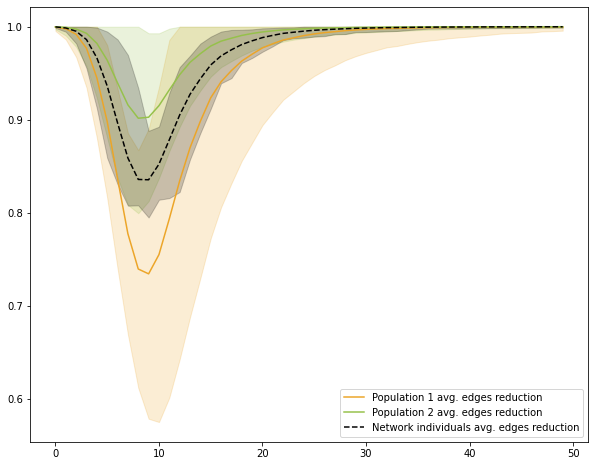

In [25]:
plt.figure(figsize=(10,8))

plt.plot(range(50), df[df['pop']==1]['mean'][0:50],'#ECA528', label="Population 1 avg. edges reduction")
plt.fill_between(range(50),
                df[df['pop']==1]['lower'][0:50],
                df[df['pop']==1]['upper'][0:50],
                color='#ECA528', alpha=0.2)

plt.plot(range(50), df[df['pop']==2]['mean'][0:50],'#96C14B', label="Population 2 avg. edges reduction")
plt.fill_between(range(50),
                df[df['pop']==2]['lower'][0:50],
                df[df['pop']==2]['upper'][0:50],
                color='#96C14B', alpha=0.2)

plt.plot(mean_all[0:50], linestyle='--', color='k', label="Network individuals avg. edges reduction")
plt.fill_between(range(50), upper_all[0:50], lower_all[0:50], color='k', alpha=0.2)

plt.legend(loc="lower right")
plt.show()

## Sensitivity to network connectivity
***Review experiments and polish them for appendix***

Experiment with Erdos-Renyi

In [26]:
bepidist_data_c = pd.read_csv('./Data/bepidist_ntwk_conn_erdos_renyi_1000.csv')
bepidist_data_c = bepidist_data_c.groupby(['ped'], as_index=False).agg({'day_lags': ['mean', 'max', 'min', 'std']})
bepidist_data_c.columns = bepidist_data_c.columns.droplevel()
bepidist_data_c.columns = ['ped', 'mean', 'max', 'min', 'std']
bepidist_data_c['lower'] = bepidist_data_c['mean'] - bepidist_data_c['std']
bepidist_data_c['lower'] = bepidist_data_c['lower'].apply(lambda x: max(x, 0))
bepidist_data_c['upper'] = bepidist_data_c['mean'] + bepidist_data_c['std']
bepidist_data_c = bepidist_data_c[bepidist_data_c['ped']>=0.01]
bepidist_data_c

,ped,mean,max,min,std,lower,upper
9,0.010,9.24,20,0,4.340413,4.899587,13.580413
10,0.011,9.24,14,0,3.414017,5.825983,12.654017
11,0.012,9.36,18,0,2.876790,6.483210,12.236790
12,0.013,8.90,14,0,2.573412,6.326588,11.473412
13,0.014,8.54,12,0,2.260666,6.279334,10.800666
...,...,...,...,...,...,...,...
95,0.096,0.04,1,0,0.197949,0.000000,0.237949
96,0.097,0.04,1,0,0.197949,0.000000,0.237949
97,0.098,0.10,1,0,0.303046,0.000000,0.403046
98,0.099,0.10,1,0,0.303046,0.000000,0.403046


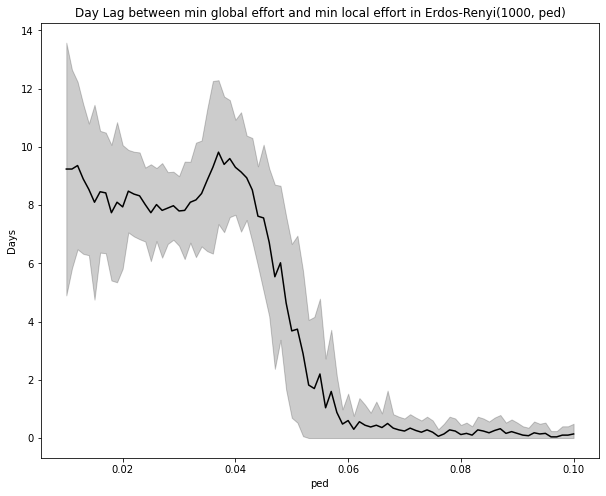

In [27]:
plt.figure(figsize=(10,8))
plt.plot(bepidist_data_c['ped'], bepidist_data_c['mean'], '-k', label="Network avg. edges reduction")
plt.fill_between(bepidist_data_c['ped'], bepidist_data_c['lower'], bepidist_data_c['upper'], color="k", alpha=0.2)
plt.title("Day Lag between min global effort and min local effort in Erdos-Renyi(1000, ped)")
plt.xlabel("ped")
plt.ylabel("Days")
plt.show()

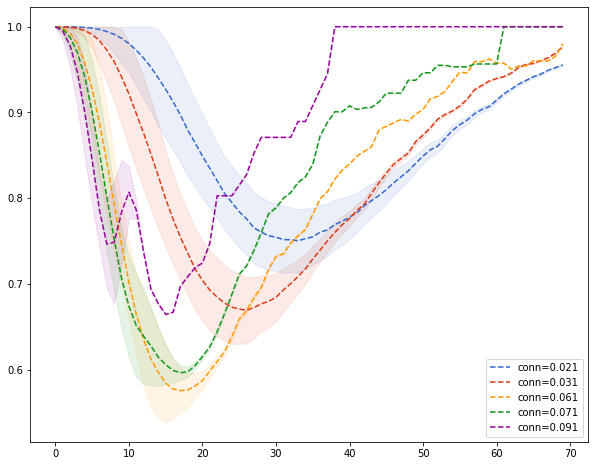

In [28]:
def transform_data(n, ped):

    dat_ = pd.read_csv(f'./Data/bepidist_contacts_ntwk_conn_erdos_renyi_{n}_{ped}.csv')
    dat_['i'] = dat_['i']/n
    dat_ = dat_.groupby(['day'], as_index=False).agg({'i': ['mean', 'max', 'min', 'std'], 
                                                    'edgecount': ['mean', 'max', 'min', 'std'],
                                                    'suscedgecount': ['mean', 'max', 'min', 'std']
                                                   })
    dat_.columns = dat_.columns.droplevel()
    dat_.columns = ['day', 'i_mean', 'i_max', 'i_min', 'i_std',
                    'edgecount_mean', 'edgecount_max', 'edgecount_min', 'edgecount_std',
                    'suscedgecount_mean', 'suscedgecount_max', 'suscedgecount_min', 'suscedgecount_std']
    
    dat_['i_lower'] = dat_['i_mean'] - dat_['i_std']
    dat_['i_lower'] = dat_['i_lower'].apply(lambda x: max(x,0))
    
    dat_['i_upper'] = dat_['i_mean'] + dat_['i_std']
    dat_['i_upper'] = dat_['i_upper'].apply(lambda x: min(x,1))
    
    dat_['edgecount_lower'] = dat_['edgecount_mean'] - dat_['edgecount_std']
    dat_['edgecount_lower'] = dat_['edgecount_lower'].apply(lambda x: max(x,0))
    dat_['edgecount_upper'] = dat_['edgecount_mean'] + dat_['edgecount_std']
    dat_['edgecount_upper'] = dat_['edgecount_upper'].apply(lambda x: min(x,1))
    
    dat_['suscedgecount_lower'] = dat_['suscedgecount_mean'] - dat_['edgecount_std']
    dat_['suscedgecount_lower'] = dat_['suscedgecount_lower'].apply(lambda x: max(x,0))
    dat_['suscedgecount_upper'] = dat_['suscedgecount_mean'] + dat_['edgecount_std']
    dat_['suscedgecount_upper'] = dat_['suscedgecount_upper'].apply(lambda x: min(x,1))
    
    return dat_

conns = [round(conn, 4) for conn in np.linspace(0.001, 0.1, 100)]
sample_conns = [conns[i] for i in range(0,len(conns),10)]

sample_conns = [0.021, 0.031, 0.061, 0.071, 0.091]

plt.figure(figsize=(10,8))

mins_reds_days = []
mins_reds = []

for idx, sampconn in enumerate(sample_conns):
    
    maxd = 70
    dat_ = transform_data(500, sampconn)
    
    plt.plot(dat_['suscedgecount_mean'][0:maxd],color=px.colors.qualitative.G10[idx], label=f"conn={sampconn}", linestyle='dashed')
    plt.fill_between(range(maxd), dat_['suscedgecount_lower'][0:maxd], dat_['suscedgecount_upper'][0:maxd],
                     color=px.colors.qualitative.G10[idx], alpha=0.1)
    
plt.legend(loc="lower right")
plt.show()

### Barabasi Albert Network

In [30]:
bepidist_data_ba = pd.read_csv('./Data/bepidist_ntwk_barabasi_albert_1000.csv')
bepidist_data_ba = bepidist_data_ba.groupby(['m'], as_index=False).agg({'day_lags': ['mean', 'max', 'min', 'std']})
bepidist_data_ba.columns = bepidist_data_ba.columns.droplevel()
bepidist_data_ba.columns = ['m', 'mean', 'max', 'min', 'std']
bepidist_data_ba['lower'] = bepidist_data_ba['mean'] - bepidist_data_ba['std']
bepidist_data_ba['lower'] = bepidist_data_ba['lower'].apply(lambda x: max(x, 0))
bepidist_data_ba['upper'] = bepidist_data_ba['mean'] + bepidist_data_ba['std']
bepidist_data_ba.head(10)

,m,mean,max,min,std,lower,upper
0,5,7.56,13,0,3.393631,4.166369,10.953631
1,6,6.36,12,0,3.305901,3.054099,9.665901
2,7,7.52,13,0,2.719844,4.800156,10.239844
3,8,6.72,12,0,2.642201,4.077799,9.362201
4,9,7.52,13,0,2.168795,5.351205,9.688795
5,10,7.06,10,0,1.856154,5.203846,8.916154
6,11,6.42,10,0,2.348165,4.071835,8.768165
7,12,6.30,10,5,1.129385,5.170615,7.429385
8,13,5.86,9,0,2.030482,3.829518,7.890482
9,14,6.30,11,0,2.052873,4.247127,8.352873


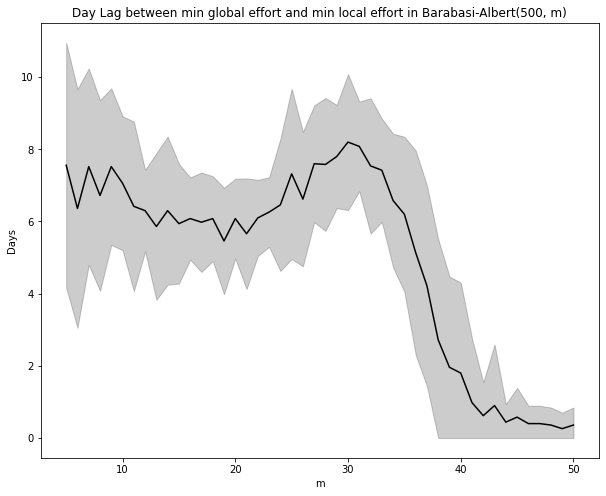

In [31]:
plt.figure(figsize=(10,8))
days = 50
plt.plot(bepidist_data_ba['m'], bepidist_data_ba['mean'],'-k', label="Network avg. edges reduction")
plt.fill_between(bepidist_data_ba['m'], bepidist_data_ba['lower'], bepidist_data_ba['upper'], color="k", alpha=0.2)
plt.title("Day Lag between min global effort and min local effort in Barabasi-Albert(500, m)")
plt.xlabel("m")
plt.ylabel("Days")
plt.show()

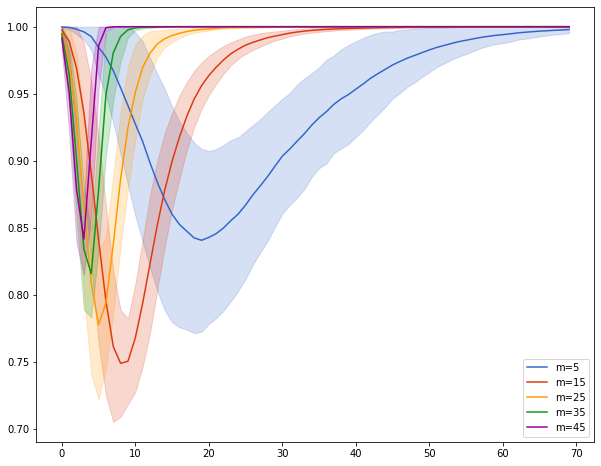

In [33]:
def transform_data(n, m):

    dat_ = pd.read_csv(f'./Data/bepidist_contacts_ntwk_barabasi_albert_{n}_{m}.csv')
    dat_['i'] = dat_['i']/n
    dat_ = dat_.groupby(['day'], as_index=False).agg({'i': ['mean', 'max', 'min', 'std'], 
                                                    'edgecount': ['mean', 'max', 'min', 'std'],
                                                    'suscedgecount': ['mean', 'max', 'min', 'std']
                                                   })
    dat_.columns = dat_.columns.droplevel()
    dat_.columns = ['day', 'i_mean', 'i_max', 'i_min', 'i_std',
                    'edgecount_mean', 'edgecount_max', 'edgecount_min', 'edgecount_std',
                    'suscedgecount_mean', 'suscedgecount_max', 'suscedgecount_min', 'suscedgecount_std']
    
    dat_['i_lower'] = dat_['i_mean'] - dat_['i_std']
    dat_['i_lower'] = dat_['i_lower'].apply(lambda x: max(x,0))
    
    dat_['i_upper'] = dat_['i_mean'] + dat_['i_std']
    dat_['i_upper'] = dat_['i_upper'].apply(lambda x: min(x,1))
    
    dat_['edgecount_lower'] = dat_['edgecount_mean'] - dat_['edgecount_std']
    dat_['edgecount_lower'] = dat_['edgecount_lower'].apply(lambda x: max(x,0))
    dat_['edgecount_upper'] = dat_['edgecount_mean'] + dat_['edgecount_std']
    dat_['edgecount_upper'] = dat_['edgecount_upper'].apply(lambda x: min(x,1))
    
    dat_['suscedgecount_lower'] = dat_['suscedgecount_mean'] - dat_['edgecount_std']
    dat_['suscedgecount_lower'] = dat_['suscedgecount_lower'].apply(lambda x: max(x,0))
    dat_['suscedgecount_upper'] = dat_['suscedgecount_mean'] + dat_['edgecount_std']
    dat_['suscedgecount_upper'] = dat_['suscedgecount_upper'].apply(lambda x: min(x,1))
    
    return dat_

mms = [5,15,25,35,45]

plt.figure(figsize=(10,8))

mins_reds_days = []
mins_reds = []

for idx, m in enumerate(mms):
    
    maxd = 70
    dat_ = transform_data(500, m)
    
    plt.plot(dat_['edgecount_mean'][0:maxd],color=px.colors.qualitative.G10[idx], label=f"m={m}")
    plt.fill_between(range(maxd), dat_['edgecount_lower'][0:maxd], dat_['edgecount_upper'][0:maxd],
                     color=px.colors.qualitative.G10[idx], alpha=0.2)
    
plt.legend(loc="lower right")
plt.show()

### Small world network

- n : int
The number of nodes

- k : int
Each node is connected to k nearest neighbors in ring topology

- p : float
The probability of rewiring each edge

In [35]:
bepidist_data_sw = pd.read_csv('./Data/bepidist_ntwk_small_world_1000.csv')
bepidist_data_sw = bepidist_data_sw.groupby(['m', 'ped'], as_index=False).agg({'day_lags': ['mean', 'max', 'min', 'std']})
bepidist_data_sw.columns = bepidist_data_sw.columns.droplevel()
bepidist_data_sw.columns = ['m', 'ped', 'mean', 'max', 'min', 'std']
bepidist_data_sw['lower'] = bepidist_data_sw['mean'] - bepidist_data_sw['std']
bepidist_data_sw['lower'] = bepidist_data_sw['lower'].apply(lambda x: max(x, 0))
bepidist_data_sw['upper'] = bepidist_data_sw['mean'] + bepidist_data_sw['std']
bepidist_data_sw

,m,ped,mean,max,min,std,lower,upper
0,5,0.001,7.74,117,0,20.459826,0.000000,28.199826
1,5,0.012,5.94,69,0,13.492870,0.000000,19.432870
2,5,0.023,9.78,107,0,23.331935,0.000000,33.111935
3,5,0.034,11.50,134,-4,30.241376,0.000000,41.741376
4,5,0.045,6.82,126,-11,20.248144,0.000000,27.068144
...,...,...,...,...,...,...,...,...
95,50,0.056,1.84,6,0,1.113186,0.726814,2.953186
96,50,0.067,1.86,9,0,1.414358,0.445642,3.274358
97,50,0.078,1.74,7,0,1.290626,0.449374,3.030626
98,50,0.089,1.36,10,0,1.453497,0.000000,2.813497


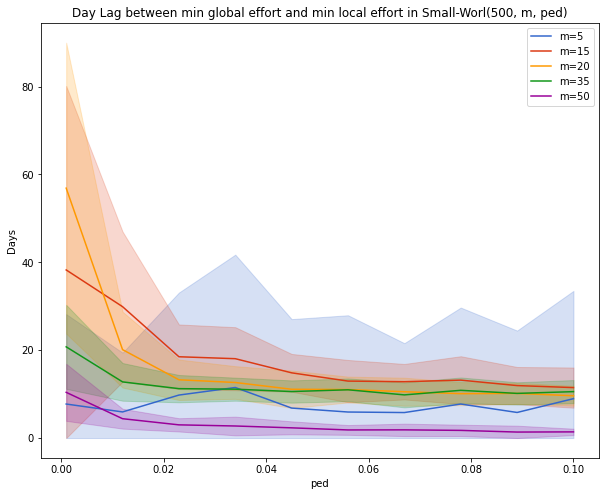

In [36]:
plt.figure(figsize=(10,8))
mms = bepidist_data_sw['m'].unique()
mms = [5, 15, 20, 35, 50]
for idx, m in enumerate(mms):
    dat = bepidist_data_sw[bepidist_data_sw['m'] == m]
    plt.plot(dat['ped'], dat['mean'], color=px.colors.qualitative.G10[idx],
             label=f"m={m}")
    plt.fill_between(dat['ped'], dat['lower'], dat['upper'], color=px.colors.qualitative.G10[idx], alpha=0.2)
plt.title("Day Lag between min global effort and min local effort in Small-Worl(500, m, ped)")
plt.xlabel("ped")
plt.ylabel("Days")
plt.legend(loc="upper right")
plt.show()

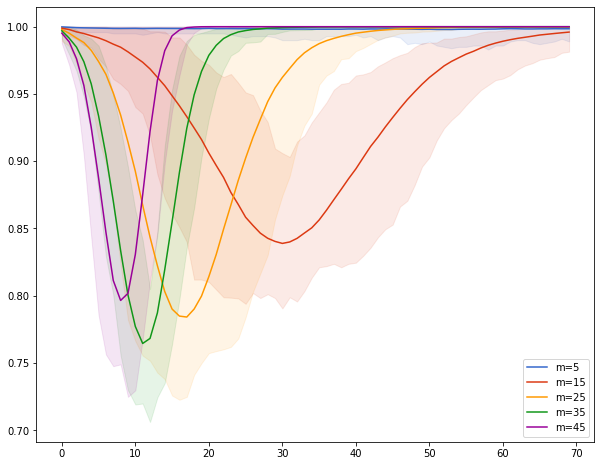

In [38]:
def transform_data(n, m, ped):

    dat_ = pd.read_csv(f'./Data/bepidist_contacts_ntwk_small_world_{n}_{m}_{ped}.csv')
    dat_['i'] = dat_['i']/n
    dat_ = dat_.groupby(['day'], as_index=False, dropna=False).agg({'i': ['mean', 'max', 'min', 'std'], 
                                                    'edgecount': ['mean', 'max', 'min', 'std'],
                                                    'suscedgecount': ['mean', 'max', 'min', 'std']
                                                   })
    dat_.columns = dat_.columns.droplevel()
    dat_.columns = ['day', 'i_mean', 'i_max', 'i_min', 'i_std',
                    'edgecount_mean', 'edgecount_max', 'edgecount_min', 'edgecount_std',
                    'suscedgecount_mean', 'suscedgecount_max', 'suscedgecount_min', 'suscedgecount_std']
    
    dat_['i_lower'] = dat_['i_mean'] - dat_['i_std']
    dat_['i_lower'] = dat_['i_lower'].apply(lambda x: max(x,0))
    
    dat_['i_upper'] = dat_['i_mean'] + dat_['i_std']
    dat_['i_upper'] = dat_['i_upper'].apply(lambda x: min(x,1))
    
    dat_['edgecount_lower'] = dat_['edgecount_mean'] - dat_['edgecount_std']
    dat_['edgecount_lower'] = dat_['edgecount_lower'].apply(lambda x: max(x,0))
    dat_['edgecount_upper'] = dat_['edgecount_mean'] + dat_['edgecount_std']
    dat_['edgecount_upper'] = dat_['edgecount_upper'].apply(lambda x: min(x,1))
    
    dat_['suscedgecount_lower'] = dat_['suscedgecount_mean'] - dat_['edgecount_std']
    dat_['suscedgecount_lower'] = dat_['suscedgecount_lower'].apply(lambda x: max(x,0))
    dat_['suscedgecount_upper'] = dat_['suscedgecount_mean'] + dat_['edgecount_std']
    dat_['suscedgecount_upper'] = dat_['suscedgecount_upper'].apply(lambda x: min(x,1))
    
    return dat_

mms = [5,15,25,35,45]

plt.figure(figsize=(10,8))

mins_reds_days = []
mins_reds = []

for idx, m in enumerate(mms):
    
    maxd = 70
    dat_ = transform_data(500, m, 0.078)

    plt.plot(dat_['edgecount_mean'][0:maxd],color=px.colors.qualitative.G10[idx], label=f"m={m}")
    plt.fill_between(range(maxd), dat_['edgecount_min'][0:maxd], dat_['edgecount_max'][0:maxd],
                     color=px.colors.qualitative.G10[idx], alpha=0.1)

plt.legend(loc="lower right")
plt.show()

## Articles of interest:
- https://www.pnas.org/doi/10.1073/pnas.2123355119
- https://journals.aps.org/pre/pdf/10.1103/PhysRevE.88.042802
- https://journals.aps.org/pre/pdf/10.1103/PhysRevE.77.066101
- https://journals.aps.org/prl/pdf/10.1103/PhysRevLett.96.208701
- https://www.sciencedirect.com/science/article/pii/S0022039618304182
- https://ieeexplore.ieee.org/abstract/document/8502826

# Comparison with adaptive SIR model

In [40]:
from SIR_adaptive import RunAdaptiveSim, SIRB

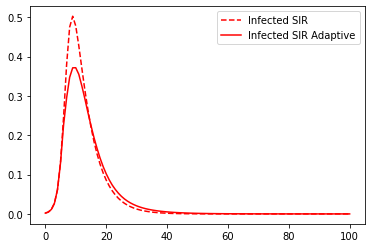

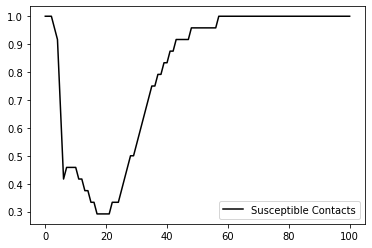

In [41]:
# Initial conditions
s0 = 499
i0 = 1
r0 = 0
n = s0 + i0 + r0

# Population parameters
Lambda = 0 # Mortality rate is mu = Lambda/N
Mu = Lambda/n

# Disease parameters
Beta = 0.045
Gamma = 0.2

# Optimization parameters
T = 14
Nu = 0.1
Delta = 0.99986
maxcr = 24
cred = 1
iutred = 0

# Final time 
tft = 100 
# Timestep lengths 
DeltaT = 1

# Infected and recovered contacts rates (fixed) *)
ci = int(maxcr)
cr = int(maxcr)

s, i, r, ctime = RunAdaptiveSim(s0, i0, r0,
               Lambda, Beta, Gamma, 
               T, Nu, Delta,
               maxcr, cred, iutred,
               tft, DeltaT)

s1, i1, r1 = SIRB([s0, i0, r0],
                  [Lambda, Mu], [Beta, Gamma], 
                  [ctime[0], ci, cr], 
                  [0, tft+1], steps=None)

ctime = [c/maxcr for c in ctime]
i = [ii/n for ii in i]
i1 = [ii1/n for ii1 in i1]

# plt.figure()
# plt.plot(s1,'#5E81B5', linestyle='dashed', label="Susceptibles SIR")
# plt.plot(s,'#5E81B5', label="Susceptibles SIR Adaptive")
# plt.legend(loc="upper right")

plt.figure()
plt.plot(i1,'red', linestyle='dashed', label="Infected SIR")
plt.plot(i,'red', label="Infected SIR Adaptive")
plt.legend(loc="upper right")

# plt.figure()
# plt.plot(r1,'-k', linestyle='dashed', label="Recovered SIR")
# plt.plot(r,'-k', label="Recovered SIR Adaptive")
# plt.legend(loc="upper right")

plt.figure()
plt.plot(ctime,'-k', label="Susceptible Contacts")
plt.legend(loc="lower right")

In [42]:
bepidist = pd.read_csv('./Data/ExampleNetworkNodes_bepidist.csv')
i_net = [i/500 for i in bepidist['i_mean']]

In [44]:
### Compare to network adaptive.
bepcontacts = pd.read_csv('./Data/ExampleNetworkNodes_contacts.csv')
bepcontacts = bepcontacts[bepcontacts['index']==0]

print(bepcontacts.shape)

bepcontacts_long = pd.melt(bepcontacts, id_vars=['index', 'node'],
                           value_vars=[col for col in bepcontacts.columns if col.startswith('day')])
bepcontacts_long_max = bepcontacts_long.groupby(['index', 'node'])['value'].max().reset_index()
bepcontacts_long_max.columns = ['index', 'node', 'value_max']
bepcontacts_long_norm = bepcontacts_long.merge(bepcontacts_long_max, left_on=['index', 'node'], right_on=['index', 'node'])
bepcontacts_long_norm['norm_value'] = bepcontacts_long_norm['value']/bepcontacts_long_norm['value_max']
bepcontacts_long_norm = bepcontacts_long_norm.rename(columns={'variable':'day'})
bepcontacts_long_norm['day'] = bepcontacts_long_norm['day'].apply(lambda x: int(x.replace('day_','')))

bepcontacts_long_norm

(500, 802)


,index,node,day,value,value_max,norm_value
0,0,0,0,26,26,1.0
1,0,0,1,26,26,1.0
2,0,0,2,26,26,1.0
3,0,0,3,26,26,1.0
4,0,0,4,26,26,1.0
...,...,...,...,...,...,...
99995,0,499,195,27,27,1.0
99996,0,499,196,27,27,1.0
99997,0,499,197,27,27,1.0
99998,0,499,198,27,27,1.0


In [46]:
df2 = pd.melt(bepcontacts, id_vars=['node'],
        value_vars=[col for col in bepcontacts.columns if col.startswith('s_')])
df2.columns = ['node', 'day', 'susceptible']
df2['day'] = df2['day'].apply(lambda x: int(x.replace('s_day_', '')))
df_susc_ctcs = bepcontacts_long_norm.merge(df2, left_on=['node','day'], right_on=['node','day'])
df_susc_ctcs = df_susc_ctcs[df_susc_ctcs['susceptible']==1]
df_susc_ctcs = df_susc_ctcs.groupby(['day'], as_index=False).agg({'norm_value': ['mean', 'max', 'min', 'std']})
df_susc_ctcs.columns = df_susc_ctcs.columns.droplevel()
df_susc_ctcs.columns = ['day', 'mean', 'max', 'min', 'std']
df_susc_ctcs

,day,mean,max,min,std
0,0,1.000000,1.000000,1.000000,0.000000
1,1,1.000000,1.000000,1.000000,0.000000
2,2,0.999904,1.000000,0.952381,0.002138
3,3,0.998774,1.000000,0.904762,0.007466
4,4,0.996958,1.000000,0.900000,0.012533
...,...,...,...,...,...
59,59,0.857143,0.857143,0.857143,NaN
60,60,0.857143,0.857143,0.857143,NaN
61,61,0.857143,0.857143,0.857143,NaN
62,62,0.857143,0.857143,0.857143,NaN


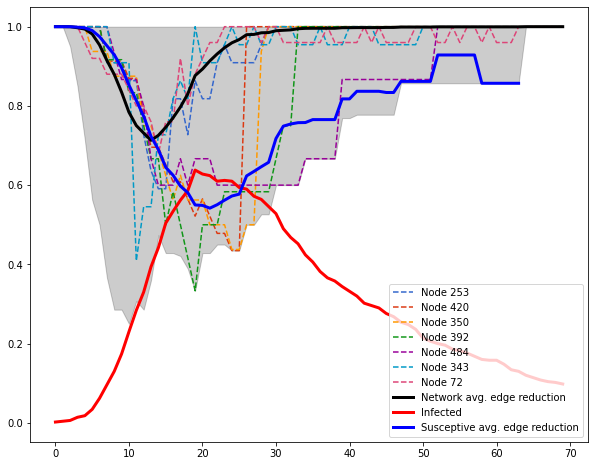

In [47]:
df = bepcontacts_long_norm.copy()
df = df[df['day']<70]
sample_nodes = [253, 420, 350, 392, 484, 343, 72]

df = df[df['node'].isin(sample_nodes)]

df_agg = bepcontacts_long_norm.copy()
df_agg = df_agg[df_agg['day']<70]
df_agg = df_agg.groupby(['day'], as_index=False).agg({'norm_value': ['mean', 'max', 'min', 'std']})
df_agg.columns = df_agg.columns.droplevel()
df_agg.columns = ['day', 'mean', 'max', 'min', 'std']
df_agg['lower'] = df_agg['mean'] - df_agg['std']
df_agg['upper'] = df_agg['mean'] + df_agg['std']
df_agg['upper'] = df_agg['upper'].apply(lambda x: min(x, 1))

plt.figure(figsize=(10,8))
for idx, node in enumerate(sample_nodes):
    plt.plot(range(70), df[df['node'] == node]['norm_value'],px.colors.qualitative.G10[idx], linestyle='dashed', label=f'Node {node}')
plt.plot(range(70), df_agg['mean'],'-k', label="Network avg. edge reduction", linewidth=3)
plt.fill_between(range(70), df_agg['min'], df_agg['max'], color="k", alpha=0.2)
plt.plot(range(70), i_net[0:70],'red', label="Infected", linewidth=3)
plt.plot(df_susc_ctcs['mean'],'blue', label="Susceptive avg. edge reduction", linewidth=3)
plt.legend(loc="lower right")

Different adaptation process for each node.

#### Simple layers example: see in notebook `adaptive_layer_experiment.ipynb`

### Max edge reduction depending on network connectivity

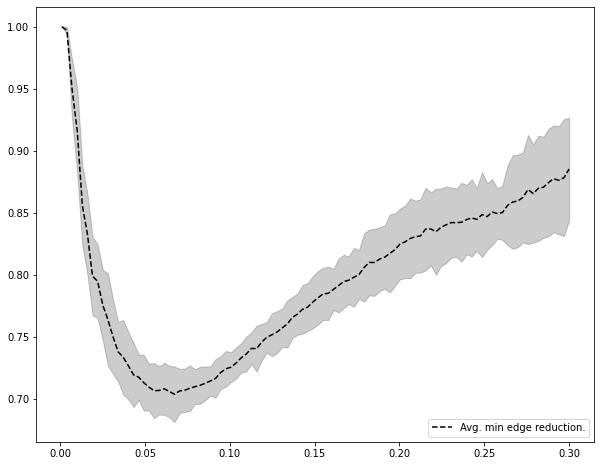

In [7]:
df_ = pd.read_csv('./Data/bepidist_erdos_renyi_500_min_mean_effort.csv')
df_['lower_effort'] = df_['mean_effort'] - 3*df_['std_effort']
df_['upper_effort'] = df_['mean_effort'] + 3*df_['std_effort']
df_['lower_effort'] = df_['lower_effort'].apply(lambda x: max(x, 0))
df_['upper_effort'] = df_['upper_effort'].apply(lambda x: min(x, 1))
plt.figure(figsize=(10,8))
plt.plot(df_['ped'], df_['mean_effort'], color = 'k',
         linestyle='dashed', label='Avg. min edge reduction.')
plt.fill_between(df_['ped'], df_['lower_effort'], df_['upper_effort'], color="k", alpha=0.2)
plt.legend(loc="lower right")
plt.show()

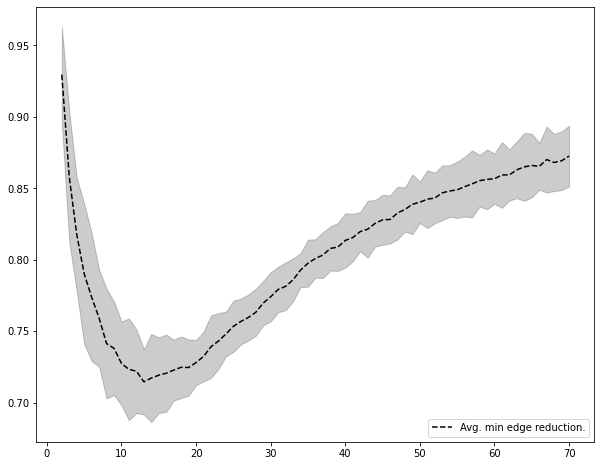

In [11]:
df_ = pd.read_csv('./Data/bepidist_barabasi_albert_500_min_mean_effort.csv')
df_['lower_effort'] = df_['mean_effort'] - 3*df_['std_effort']
df_['upper_effort'] = df_['mean_effort'] + 3*df_['std_effort']
df_['lower_effort'] = df_['lower_effort'].apply(lambda x: max(x, 0))
df_['upper_effort'] = df_['upper_effort'].apply(lambda x: min(x, 1))
plt.figure(figsize=(10,8))
plt.plot(df_['m'], df_['mean_effort'], color = 'k',
         linestyle='dashed', label='Avg. min edge reduction.')
plt.fill_between(df_['m'], df_['lower_effort'], df_['upper_effort'], color="k", alpha=0.2)
plt.legend(loc="lower right")
plt.show()

### Infected dropping contacts
We added also behaviour having infected nodes droping contacts.
The method was having infected nodes droping nodes randomly with a proportion that expresses their risk sensitivity.

The result is that when infected nodes also drop contacts, the burden on edge reduction on susceptibles is diminished and the local behavior tends to become closer to the global behavior.

Below are some results.

In [73]:
bepidist_no_drop = pd.read_csv('./Data/20251102092420_bepidist_0.05_7_figure_data.csv')
bepidist_drop = pd.read_csv('./Data/20251102092744_bepidist_0.05_7_figure_data.csv')
bepidist_no_drop = bepidist_no_drop.apply(pd.to_numeric)
bepidist_drop = bepidist_drop.apply(pd.to_numeric)

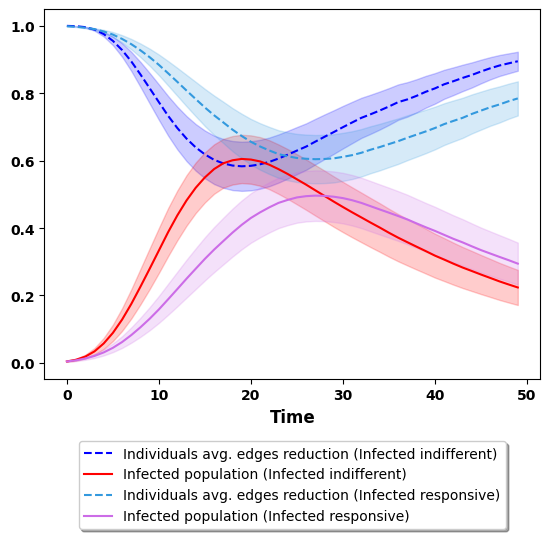

In [95]:
i_mean = bepidist_no_drop['i_mean'].astype(float).tolist()
i_mean = [i/500 for i in i_mean]
i_min = [m*(0.7 + (1 - (1-m))*0.3) for m in i_mean]
i_max = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in i_mean]
mean_all = bepidist_no_drop['edgecount_mean'].astype(float).tolist()
lower_all = [m*(0.7 + (1 - (1-m))*0.3) for m in mean_all] # bepidist['edgecount_min'].astype(float).tolist()
upper_all = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in mean_all] # bepidist['edgecount_max'].astype(float).tolist()
mean_sus = bepidist_no_drop['suscedgecount_mean'].astype(float).tolist()
lower_sus = [m*(0.7 + (1 - (1-m))*0.3) for m in mean_sus] #  bepidist['suscedgecount_min'].astype(float).tolist()
upper_sus = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in mean_sus] # bepidist['suscedgecount_max'].astype(float).tolist()

i_mean_drop = bepidist_drop['i_mean'].astype(float).tolist()
i_mean_drop = [i/500 for i in i_mean_drop]
i_min_drop = [m*(0.7 + (1 - (1-m))*0.3) for m in i_mean_drop]
i_max_drop = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in i_mean_drop]
mean_all_drop = bepidist_drop['edgecount_mean'].astype(float).tolist()
lower_all_drop = [m*(0.7 + (1 - (1-m))*0.3) for m in mean_all_drop] # bepidist['edgecount_min'].astype(float).tolist()
upper_all_drop = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in mean_all_drop] # bepidist['edgecount_max'].astype(float).tolist()
mean_sus_drop = bepidist_drop['suscedgecount_mean'].astype(float).tolist()
lower_sus_drop = [m*(0.7 + (1 - (1-m))*0.3) for m in mean_sus_drop] #  bepidist['suscedgecount_min'].astype(float).tolist()
upper_sus_drop = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in mean_sus_drop] # bepidist['suscedgecount_max'].astype(float).tolist()

top = 50

plt.figure()

# No drop
# plt.plot(mean_all[0:top],'-k', label="Network avg. edges reduction (Infected indifferent)")
# plt.fill_between(range(top), upper_all[0:top], lower_all[0:top], color="k", alpha=0.2)
plt.plot(mean_sus[0:top], linestyle='--', color='b', label="Individuals avg. edges reduction (Infected indifferent)")
plt.fill_between(range(top), upper_sus[0:top], lower_sus[0:top], color="b", alpha=0.2)
plt.plot(i_mean[0:top],'-r', label="Infected population (Infected indifferent)")
plt.fill_between(range(top), i_max[0:top], i_min[0:top], color="r", alpha=0.2)

# Drop
# plt.plot(mean_all_drop[0:top],'#DEAB57', label="Network avg. edges reduction (Infected responsive)")
# plt.fill_between(range(top), upper_all_drop[0:top], lower_all_drop[0:top], color="#DEAB57", alpha=0.2)
plt.plot(mean_sus_drop[0:top], linestyle='--', color='#3399DE', label="Individuals avg. edges reduction (Infected responsive)")
plt.fill_between(range(top), upper_sus_drop[0:top], lower_sus_drop[0:top], color="#3399DE", alpha=0.2)
plt.plot(i_mean_drop[0:top],'#CC6CE7', label="Infected population (Infected responsive)")
plt.fill_between(range(top), i_max_drop[0:top], i_min_drop[0:top], color="#CC6CE7", alpha=0.2)

ax = plt.gca() # Get current axes
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fancybox=True, shadow=True, ncol=1)

ax.set_xlabel("Time", fontsize=12, fontweight='bold')
# plt.ylabel("Planning horizon (days)")

plt.show()

### Adaptive parameters vs peak times, final sizes, peak sizes

Do simulations changing the behavioral profile (ν) and explore the impact on
final and peak sizes, and peak times.
Do two scatter plots: 1) risk sensitivity (ν) vs final size, 2) planning horizon
for a selected risk sensitivity vs peak size.  IN PROGRESS.

In [94]:
# epidist_data = pd.read_csv('./Data/20251101184108_epidist_heatmap_data.csv')
# bepidist_data = pd.read_csv('./Data/20251101184108_bepidist_heatmap_data.csv')
# epidist_data = epidist_data.apply(pd.to_numeric)
# bepidist_data = bepidist_data.apply(pd.to_numeric)
# print(bepidist_data['V'].unique().tolist())
# print(bepidist_data['T'].unique().tolist())

### Delay
We made some simulations with delay times. Sometimes information is not available immediately. For the optimization process, susceptible individuals need to know how many of their neighbors are infected. This information may take some days to be available. Hence we modified the adaptive algorithm to use the infected array from prior days. Below are the results.

COnclusions:

In [109]:
bepidist_no_delay = pd.read_csv('./Data/20251102092420_bepidist_0.05_7_figure_data.csv')
bepidist_delay = pd.read_csv('./Data/20251102105921_bepidist_0.05_7_figure_data.csv') 
# 20251102103221_bepidist_0.05_7_figure_data.csv 1 days delay
# 20251102104523_bepidist_0.05_7_figure_data.csv 2 days delay
# 20251102105921_bepidist_0.05_7_figure_data.csv 3 days delay
bepidist_no_delay = bepidist_no_delay.apply(pd.to_numeric)
bepidist_delay = bepidist_delay.apply(pd.to_numeric)

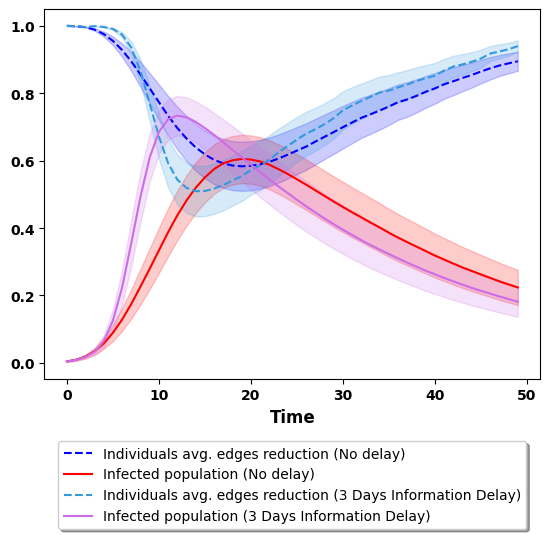

In [111]:
i_mean = bepidist_no_delay['i_mean'].astype(float).tolist()
i_mean = [i/500 for i in i_mean]
i_min = [m*(0.7 + (1 - (1-m))*0.3) for m in i_mean]
i_max = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in i_mean]
mean_all = bepidist_no_delay['edgecount_mean'].astype(float).tolist()
lower_all = [m*(0.7 + (1 - (1-m))*0.3) for m in mean_all] # bepidist['edgecount_min'].astype(float).tolist()
upper_all = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in mean_all] # bepidist['edgecount_max'].astype(float).tolist()
mean_sus = bepidist_no_delay['suscedgecount_mean'].astype(float).tolist()
lower_sus = [m*(0.7 + (1 - (1-m))*0.3) for m in mean_sus] #  bepidist['suscedgecount_min'].astype(float).tolist()
upper_sus = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in mean_sus] # bepidist['suscedgecount_max'].astype(float).tolist()

i_mean_delay = bepidist_delay['i_mean'].astype(float).tolist()
i_mean_delay = [i/500 for i in i_mean_delay]
i_min_delay = [m*(0.7 + (1 - (1-m))*0.3) for m in i_mean_delay]
i_max_delay = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in i_mean_delay]
mean_all_delay = bepidist_delay['edgecount_mean'].astype(float).tolist()
lower_all_delay = [m*(0.7 + (1 - (1-m))*0.3) for m in mean_all_delay] # bepidist['edgecount_min'].astype(float).tolist()
upper_all_delay = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in mean_all_delay] # bepidist['edgecount_max'].astype(float).tolist()
mean_sus_delay = bepidist_delay['suscedgecount_mean'].astype(float).tolist()
lower_sus_delay = [m*(0.7 + (1 - (1-m))*0.3) for m in mean_sus_delay] #  bepidist['suscedgecount_min'].astype(float).tolist()
upper_sus_delay = [min(m*(1.3 - (1 - (1-m))*0.3),1) for m in mean_sus_delay] # bepidist['suscedgecount_max'].astype(float).tolist()

top = 50

plt.figure()

# No delay
# plt.plot(mean_all[0:top],'-k', label="Network avg. edges reduction (No delay)")
# plt.fill_between(range(top), upper_all[0:top], lower_all[0:top], color="k", alpha=0.2)
plt.plot(mean_sus[0:top], linestyle='--', color='b', label="Individuals avg. edges reduction (No delay)")
plt.fill_between(range(top), upper_sus[0:top], lower_sus[0:top], color="b", alpha=0.2)
plt.plot(i_mean[0:top],'-r', label="Infected population (No delay)")
plt.fill_between(range(top), i_max[0:top], i_min[0:top], color="r", alpha=0.2)

# delay
# plt.plot(mean_all_delay[0:top],'#DEAB57', label="Network avg. edges reduction (2 Days Delay)")
# plt.fill_between(range(top), upper_all_delay[0:top], lower_all_delay[0:top], color="#DEAB57", alpha=0.2)
plt.plot(mean_sus_delay[0:top], linestyle='--', color='#3399DE', label="Individuals avg. edges reduction (3 Days Information Delay)")
plt.fill_between(range(top), upper_sus_delay[0:top], lower_sus_delay[0:top], color="#3399DE", alpha=0.2)
plt.plot(i_mean_delay[0:top],'#CC6CE7', label="Infected population (3 Days Information Delay)")
plt.fill_between(range(top), i_max_delay[0:top], i_min_delay[0:top], color="#CC6CE7", alpha=0.2)

ax = plt.gca() # Get current axes
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fancybox=True, shadow=True, ncol=1)

ax.set_xlabel("Time", fontsize=12, fontweight='bold')
# plt.ylabel("Planning horizon (days)")

plt.show()